# Comparación de modelos de sueño — Jhoan Saavedra

Notebook sencillo para comparar Random Forest y LightGBM usando exactamente el mismo preprocesamiento reutilizable que consumirá FastAPI. La construcción del dataset, división por sujeto, métricas y tracking viven en el paquete `sleep-staging`.

## 1. Configuración

Para una prueba rápida puede asignarse `MAX_RECORDS = 4`. Para el experimento completo debe permanecer en `None`. MLflow está desactivado por defecto.

In [17]:
from pathlib import Path
import sys

REPO_ROOT = next(path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (path / 'data.dvc').is_file())
PACKAGE_SRC = REPO_ROOT / 'packages' / 'sleep-staging' / 'src'
if str(PACKAGE_SRC) not in sys.path:
    sys.path.insert(0, str(PACKAGE_SRC))

from IPython.display import display
from sleep_staging import PreprocessingConfig, PreprocessingPipeline
from sleep_staging.datasets import discover_sleep_telemetry_records
from sleep_staging.training import (
    MlflowConfig, compare_evaluations,
    create_lightgbm_classifier, create_random_forest_classifier,
    display_evaluation, load_or_build_supervised_dataset,
    split_by_subject, train_and_evaluate,
)

DATA_DIR = REPO_ROOT / 'data' / 'sleep-telemetry'
DATASET_CACHE_DIR = REPO_ROOT / 'data' / 'processed' / 'supervised'
SEED = 42
VALIDATION_SIZE = 0.20
MAX_RECORDS = None  # Set to None to use all records, or an integer to limit the number of records used for training and evaluation
MLFLOW = MlflowConfig(
    enabled=True,
    experiment_name='sleep_staging_model_comparison',
    tracking_uri='http://54.152.164.251:5000/',
    log_model=False,
)
PREPROCESSING = PreprocessingConfig()
PIPELINE = PreprocessingPipeline(PREPROCESSING)

## 2. Preprocesamiento y dataset

`build_supervised_dataset` ejecuta `PreprocessingPipeline.transform_edf` para cada PSG. El hipnograma se incorpora después y solo aporta las etiquetas de entrenamiento.

In [18]:
records = discover_sleep_telemetry_records(DATA_DIR)
records = records if MAX_RECORDS is None else records[:MAX_RECORDS]
dataset = load_or_build_supervised_dataset(records, PIPELINE, DATASET_CACHE_DIR)

print(f'Dataset: {dataset.features.shape[0]} épocas x {dataset.features.shape[1]} features')
print(f'Sujetos: {dataset.metadata.subject_id.nunique()} | Registros: {dataset.metadata.record_id.nunique()}')
display(dataset.labels.value_counts().rename('épocas').sort_index().to_frame())

Cargando dataset desde caché: E:\PROJECTS\Maestria Inteligencia Artificial\masterIADesarollo\micro-proyecto-grupo-7\data\processed\supervised\2c71b3937c5b
Dataset: 42691 épocas x 486 features
Sujetos: 22 | Registros: 44


,épocas
stage,
N1,3653
N2,19851
N3,6415
REM,8349
W,4423


## 3. División entrenamiento/validación por sujeto

`VALIDATION_SIZE` controla la proporción aproximada de sujetos reservada. Las dos noches de una persona siempre quedan en el mismo conjunto.

In [19]:
split = split_by_subject(dataset, validation_size=VALIDATION_SIZE, random_state=SEED)
print(f'Train: {split.X_train.shape} | {len(split.train_subjects)} sujetos')
print(f'Validación: {split.X_validation.shape} | {len(split.validation_subjects)} sujetos')
print(f'Sujetos de validación: {split.validation_subjects}')

Train: (32762, 486) | 17 sujetos
Validación: (9929, 486) | 5 sujetos
Sujetos de validación: ('S01', 'S02', 'S10', 'S15', 'S17')


## 4. Modelo Random Forest

In [42]:
RF_PARAMS =       {
        "max_depth": 18,
        "max_features": "sqrt",
        "min_samples_leaf": 3,
        "n_estimators": 500,
    }
random_forest = create_random_forest_classifier(random_state=SEED, **RF_PARAMS)
rf_evaluation = train_and_evaluate(
    random_forest, split, model_name='Random Forest',
    parameters=RF_PARAMS, mlflow_config=MLFLOW,
)

🏃 View run Random Forest at: http://54.152.164.251:5000/#/experiments/497331160501287737/runs/d7c5baf950ab43e19b902705f01a5bdc
🧪 View experiment at: http://54.152.164.251:5000/#/experiments/497331160501287737


## 5. Modelo LightGBM

LightGBM es una elección explícita. Si la dependencia no está instalada, esta celda genera un error con la instrucción de instalación; nunca cambia silenciosamente a Random Forest.

In [ ]:
LGBM_PARAMS =  {
    "boosting_type": "dart",
    "learning_rate": 0.025,
    "min_child_samples": 25,
    "n_estimators": 800,
    "num_leaves": 36,
    "max_depth": 8,
    "drop_rate": 0.10,
    "skip_drop": 0.50,
    "reg_alpha": 0.10,
    "reg_lambda": 1.50,
    "class_weight": {
        "N1": 2.20,
        "N2": 0.41,
        "N3": 1.56,
        "REM": 1.00,
        "W": 2.01,
    },
}

lightgbm = create_lightgbm_classifier(random_state=SEED, **LGBM_PARAMS)
lgbm_evaluation = train_and_evaluate(
    lightgbm, split, model_name='LightGBM',
    parameters=LGBM_PARAMS, mlflow_config=MLFLOW,
)

## 6. Resultados y matrices de confusión

,accuracy,kappa,f1_macro
LightGBM,0.7885,0.7115,0.7541
Random Forest,0.7715,0.6834,0.7320



Random Forest
accuracy    0.7715
kappa       0.6834
f1_macro    0.7320

Métricas por estadio:
     precision  recall  f1-score  support
W       0.8798  0.7821    0.8281   1161.0
N1      0.5129  0.4165    0.4597    862.0
N2      0.7111  0.9126    0.7994   3868.0
N3      0.9695  0.5913    0.7346   2207.0
REM     0.8256  0.8509    0.8381   1831.0


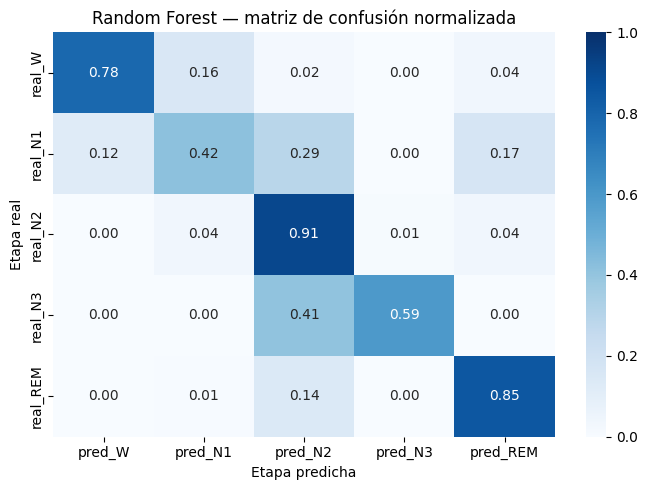


LightGBM
accuracy    0.7885
kappa       0.7115
f1_macro    0.7541

Métricas por estadio:
     precision  recall  f1-score  support
W       0.8726  0.7847    0.8263   1161.0
N1      0.4808  0.5081    0.4941    862.0
N2      0.7588  0.8798    0.8148   3868.0
N3      0.9480  0.6688    0.7843   2207.0
REM     0.8287  0.8744    0.8509   1831.0


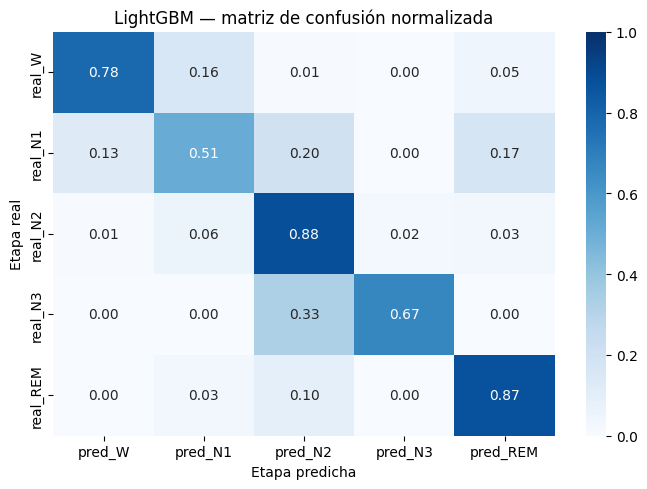

In [27]:
display(compare_evaluations(rf_evaluation, lgbm_evaluation).round(4))
display_evaluation(rf_evaluation)
display_evaluation(lgbm_evaluation)

## 7. Optimizacion adaptativa de LightGBM (5 rondas, 15 corridas)

Se ejecutaron tres candidatos por ronda sobre el mismo split por sujeto y se registraron en MLflow con nombres `LightGBM R1-*` hasta `LightGBM R5-*`. El modelo no se subio (`log_model=False`).

- Ronda 1, peso N1: `1.8`, `2.1`, `2.2`. Ganador: `2.2`, F1 N1 `0.512574`, F1 macro `0.763961`.
- Ronda 2, peso N1: `2.25`, `2.3`, `2.4`. Ninguno supero a `2.2`.
- Ronda 3, hojas: `32`, `40`, `48`. Mejor de ronda: `32`, F1 N1 `0.509574`.
- Ronda 4, dropout: `(0.05, 0.5)`, `(0.15, 0.5)`, `(0.10, 0.65)`. Mejor de ronda: `(0.10, 0.65)`, F1 N1 `0.507546`.
- Ronda 5, learning rate/arboles: `(0.02, 1000)`, `(0.03, 667)`, `(0.025, 1000)`. Mejor de ronda: `(0.03, 667)`, F1 N1 `0.507447`.

El ganador global es `LightGBM R1-C3 N1w=2.2` (`e850a590616340e6952782e15a5952c2`): precision N1 `0.475670`, recall N1 `0.555684`, F1 N1 `0.512574`, F1 macro `0.763961`, accuracy `0.794843` y kappa `0.722029`. La celda LightGBM anterior queda configurada con estos hiperparametros.